In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader


In [ ]:
# Change paths based on your folder structure
input_path = '/content/drive/MyDrive/Colab Notebooks/Input.xlsx'
output_path = '/content/drive/MyDrive/Colab Notebooks/Output.xlsx'

# Load as DataFrames
X = pd.read_excel(input_path)
y = pd.read_excel(output_path)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (1696, 13)
Output shape: (1696, 1)


In [ ]:
# Check first few rows
print(X.head())
print(y.head())

# Check for missing values
print("Missing in X:", X.isnull().sum().sum())
print("Missing in y:", y.isnull().sum().sum())


   0.32  0.32.1  0.25    0  90  90.1  1  2  0.1  0.2  0.352    6   0.11519
0  0.32    0.32  0.25  0.0  90  90.0  1  2  0.0  0.0  0.352  6.0  0.191214
1  0.32    0.32  0.25  0.0  90  90.0  1  2  0.0  0.0  0.352  6.0  0.295129
2  0.32    0.32  0.25  0.0  90  90.0  1  2  0.0  0.0  0.352  6.0  0.415551
3  0.32    0.32  0.25  0.0  90  90.0  1  2  0.0  0.0  0.352  6.0  0.530459
4  0.32    0.32  0.25  0.0  90  90.0  1  2  0.0  0.0  0.352  6.0  0.625936
   0.022274
0  0.031036
1  0.052430
2  0.089492
3  0.121766
4  0.141849
Missing in X: 0
Missing in y: 0


In [ ]:
# 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split the 30% equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (1187, 13)
Validation: (254, 13)
Test: (255, 13)


In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)


TypeError: Feature names are only supported if all input features have string names, but your input has ['float', 'int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [ ]:
X.columns


Index([               0.32,            '0.32.1',                0.25,
                         0,                  90,              '90.1',
                         1,                   2,               '0.1',
                     '0.2', 0.35200000000000004,                   6,
                   0.11519],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

# Ensure all column names are strings (prevents mixed-type error)
X_train.columns = X_train.columns.map(str)
X_val.columns = X_val.columns.map(str)
X_test.columns = X_test.columns.map(str)

# Initialize scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on training data and transform all splits
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scale output (target) as well
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

# Verify scaling
print("Mean of X_train after scaling:", X_train_scaled.mean())
print("Std of X_train after scaling:", X_train_scaled.std())
print("Mean of y_train after scaling:", y_train_scaled.mean())
print("Std of y_train after scaling:", y_train_scaled.std())
print("\n✅ Scaling successful.")


Mean of X_train after scaling: -4.926969912924031e-17
Std of X_train after scaling: 1.0
Mean of y_train after scaling: -1.3169284066320306e-16
Std of y_train after scaling: 0.9999999999999999

✅ Scaling successful.


In [ ]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

# Combine into DataLoaders for batching
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print("Data ready for model training ✅")


Data ready for model training ✅


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
class SavoniusANN(nn.Module):
    def __init__(self, input_dim=13, hidden_dim=27, output_dim=1):
        super(SavoniusANN, self).__init__()
        # Layer definitions
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # Input → Hidden
        self.fc2 = nn.Linear(hidden_dim, output_dim)  # Hidden → Output

        # Activation functions
        self.act_hidden = nn.Tanh()   # tansig
        self.act_output = nn.Identity()  # purelin (linear output)

    def forward(self, x):
        x = self.act_hidden(self.fc1(x))
        x = self.act_output(self.fc2(x))
        return x


In [ ]:
# Initialize model
model = SavoniusANN(input_dim=13, hidden_dim=27, output_dim=1)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(model)


SavoniusANN(
  (fc1): Linear(in_features=13, out_features=27, bias=True)
  (fc2): Linear(in_features=27, out_features=1, bias=True)
  (act_hidden): Tanh()
  (act_output): Identity()
)


In [ ]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)
print("✅ Weights initialized with Xavier method.")


✅ Weights initialized with Xavier method.


In [ ]:
criterion = nn.MSELoss()  # Mean Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Training parameters
num_epochs = 70              # total epochs
patience = 20                # early stopping patience
best_val_loss = float('inf') # to track best model
epochs_no_improve = 0        # counter


In [ ]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- TRAINING ----
    model.train()
    running_train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()         # reset gradients
        outputs = model(xb)           # forward pass
        loss = criterion(outputs, yb) # compute loss
        loss.backward()               # backward pass
        optimizer.step()              # update weights

        running_train_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    # ---- Log losses ----
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # ---- Early stopping check ----
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")


Epoch [1/70] | Train Loss: 1.054668 | Val Loss: 0.822376
Epoch [2/70] | Train Loss: 0.773638 | Val Loss: 0.674876
Epoch [3/70] | Train Loss: 0.692181 | Val Loss: 0.631973
Epoch [4/70] | Train Loss: 0.642216 | Val Loss: 0.588034
Epoch [5/70] | Train Loss: 0.608023 | Val Loss: 0.555249
Epoch [6/70] | Train Loss: 0.584604 | Val Loss: 0.539385
Epoch [7/70] | Train Loss: 0.567427 | Val Loss: 0.521022
Epoch [8/70] | Train Loss: 0.549623 | Val Loss: 0.504576
Epoch [9/70] | Train Loss: 0.537418 | Val Loss: 0.501180
Epoch [10/70] | Train Loss: 0.525995 | Val Loss: 0.500692
Epoch [11/70] | Train Loss: 0.517560 | Val Loss: 0.489645
Epoch [12/70] | Train Loss: 0.506824 | Val Loss: 0.478401
Epoch [13/70] | Train Loss: 0.500531 | Val Loss: 0.479582
Epoch [14/70] | Train Loss: 0.490226 | Val Loss: 0.471475
Epoch [15/70] | Train Loss: 0.482464 | Val Loss: 0.458361
Epoch [16/70] | Train Loss: 0.477025 | Val Loss: 0.455693
Epoch [17/70] | Train Loss: 0.468485 | Val Loss: 0.454435
Epoch [18/70] | Train L

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))
print("✅ Best model loaded (based on validation loss).")


✅ Best model loaded (based on validation loss).


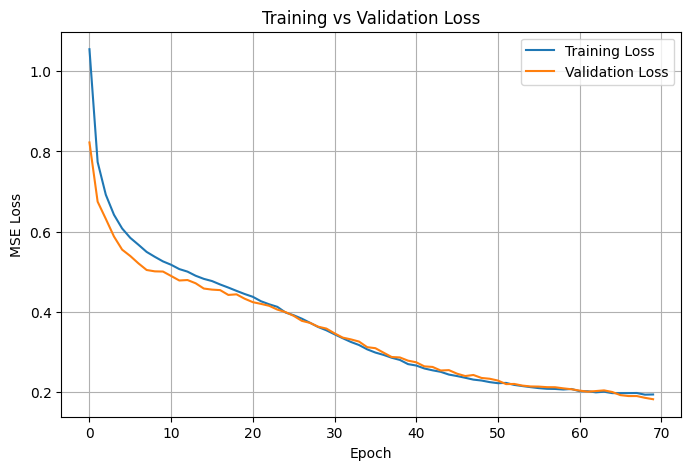

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# --- Block 1: Load Best Model ---
best_model = SavoniusANN(input_dim=13, hidden_dim=27, output_dim=1).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()  # Disable dropout, batchnorm, etc.
print("✅ Best model loaded and ready for evaluation.")

✅ Best model loaded and ready for evaluation.


In [ ]:
# --- Block 2: Evaluate Test Performance ---
from sklearn.metrics import mean_squared_error, r2_score

with torch.no_grad():
    y_pred_test = best_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

# ✅ Convert DataFrame to NumPy array before inverse scaling
y_test_np = y_test.values  # or y_test.to_numpy()

# Inverse transform targets to original scale
y_test_original = scaler_y.inverse_transform(y_test_np.reshape(-1, 1))
y_pred_original = scaler_y.inverse_transform(y_pred_test)

mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f"Test MSE: {mse:.6f}")
print(f"Test R² Score: {r2:.4f}")



Test MSE: 0.005384
Test R² Score: -84.6435


In [ ]:
print("True (actual) Power Coefficient range:", y_test_original.min(), "to", y_test_original.max())
print("Predicted Power Coefficient range:", y_pred_original.min(), "to", y_pred_original.max())


True (actual) Power Coefficient range: 0.1350673411281871 to 0.1786047979652235
Predicted Power Coefficient range: -0.0033284973 to 0.45044136


In [ ]:
with torch.no_grad():
    y_pred_test = best_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

# Clamp predictions (physically Cp must be >= 0)
y_pred_test = np.clip(y_pred_test, 0, 1)

# Inverse transform
y_test_np = y_test.to_numpy()
y_test_original = scaler_y.inverse_transform(y_test_np.reshape(-1, 1))
y_pred_original = scaler_y.inverse_transform(y_pred_test)

mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f"Test MSE: {mse:.6f}")
print(f"Test R² Score: {r2:.4f}")


Test MSE: 0.000771
Test R² Score: -11.2617


In [ ]:
import numpy as np
y_mean_pred = np.full_like(y_test_scaled, y_train_scaled.mean())
mse_baseline = np.mean((y_test_scaled - y_mean_pred) ** 2)
print("Baseline MSE (predicting mean):", mse_baseline)


Baseline MSE (predicting mean): 1.0448978687263875


In [ ]:
# --- Step 3: Evaluate Model in Original Units ---

# Unscale predictions and actuals back to original range
y_pred_original = scaler_y.inverse_transform(y_pred_test)
y_test_original = scaler_y.inverse_transform(y_test_scaled)

# Compute metrics in original (unscaled) space
from sklearn.metrics import mean_squared_error, r2_score

mse_original = mean_squared_error(y_test_original, y_pred_original)
r2_original = r2_score(y_test_original, y_pred_original)

print(f"Unscaled MSE: {mse_original:.6f}")
print(f"Unscaled R²: {r2_original:.4f}")


Unscaled MSE: 0.004919
Unscaled R²: 0.3912


In [ ]:
# --- Block 1: Enhanced Model Definition & Configurable Training ---

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# -----------------------------
# 🔧 Configurable Parameters
# -----------------------------
input_dim = X_train_scaled.shape[1]
hidden_dim = 32        # try 16, 32, 48 later
output_dim = 1
learning_rate = 0.001  # try 0.0005, 0.002
weight_decay = 1e-4    # L2 regularization; try 1e-5 to 1e-3
dropout_rate = 0.1     # try 0.0, 0.2

num_epochs = 500
patience = 40  # early stopping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 🧠 Enhanced Model Definition
# -----------------------------
class SavoniusANN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(SavoniusANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# 🧩 Training Setup
# -----------------------------
model = SavoniusANN(input_dim, hidden_dim, output_dim, dropout_rate).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)

best_val_loss = np.inf
patience_counter = 0
best_state_dict = None

# -----------------------------
# 🚀 Training Loop
# -----------------------------
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()

    # validation
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, y_val_t)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"✅ Training done. Best val MSE: {best_val_loss.item():.6f}")

# Save best model
torch.save(best_state_dict, "best_refined_model.pth")


✅ Training done. Best val MSE: 0.149688


In [ ]:
# --- Block 2: Evaluate the Refined Model ---

# Load model
refined_model = SavoniusANN(input_dim, hidden_dim, output_dim, dropout_rate).to(device)
refined_model.load_state_dict(torch.load("best_refined_model.pth"))
refined_model.eval()

# Convert data
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# Predict
with torch.no_grad():
    y_pred_test_scaled = refined_model(X_test_t).cpu().numpy()

# Inverse-transform both prediction and ground truth
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_scaled)

# Evaluate
test_mse = mean_squared_error(y_test_actual, y_pred_test)
test_r2 = r2_score(y_test_actual, y_pred_test)

print(f"Refined Model Test MSE: {test_mse:.6f}")
print(f"Refined Model Test R²: {test_r2:.4f}")


Refined Model Test MSE: 0.001912
Refined Model Test R²: 0.7634


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --- Block 1: Hidden Dimension Sweep ---
hidden_dims = [8, 16, 32, 64, 128]
results = {}

for hdim in hidden_dims:
    # Define model
    model = SavoniusANN(input_dim=13, hidden_dim=hdim, output_dim=1, dropout=0.2).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    best_state = None

    for epoch in range(70):
        # --- Train ---
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

        # --- Validate ---
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

    results[hdim] = best_val_loss.item()
    print(f"Hidden={hdim:3d} | Best Val MSE: {best_val_loss.item():.5f}")

# --- Report best configuration ---
best_hidden = min(results, key=results.get)
print("\n✅ Best Hidden Layer Size:", best_hidden)
print("Validation MSEs:", results)


TypeError: SavoniusANN.__init__() got an unexpected keyword argument 'dropout'

In [ ]:
import torch.nn as nn

class SavoniusANN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.0):
        super(SavoniusANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
import torch

# Convert scaled NumPy arrays back to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

print("✅ All tensors recreated successfully!")


✅ All tensors recreated successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --- Block 1: Hidden Dimension Sweep ---
hidden_dims = [8, 16, 32, 64, 128]
results = {}

for hdim in hidden_dims:
    # Define model
    model = SavoniusANN(input_dim=13, hidden_dim=hdim, output_dim=1, dropout=0.2).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    best_state = None

    for epoch in range(70):
        # --- Train ---
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

        # --- Validate ---
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

    results[hdim] = best_val_loss.item()
    print(f"Hidden={hdim:3d} | Best Val MSE: {best_val_loss.item():.5f}")

# --- Report best configuration ---
best_hidden = min(results, key=results.get)
print("\n✅ Best Hidden Layer Size:", best_hidden)
print("Validation MSEs:", results)


Hidden=  8 | Best Val MSE: 0.90119
Hidden= 16 | Best Val MSE: 0.64504
Hidden= 32 | Best Val MSE: 0.60152
Hidden= 64 | Best Val MSE: 0.57716
Hidden=128 | Best Val MSE: 0.52601

✅ Best Hidden Layer Size: 128
Validation MSEs: {8: 0.901187002658844, 16: 0.6450426578521729, 32: 0.6015178561210632, 64: 0.5771626830101013, 128: 0.5260128378868103}


In [ ]:
# --- Block 2: Dropout Sweep ---
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4]
results_dropout = {}

for dr in dropout_rates:
    model = SavoniusANN(input_dim=13, hidden_dim=128, output_dim=1, dropout=dr).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    best_state = None

    for epoch in range(70):
        # --- Train ---
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

        # --- Validate ---
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

    results_dropout[dr] = best_val_loss.item()
    print(f"Dropout={dr:.1f} | Best Val MSE: {best_val_loss.item():.5f}")

best_dropout = min(results_dropout, key=results_dropout.get)
print("\n✅ Best Dropout Rate:", best_dropout)
print("Validation MSEs:", results_dropout)


Dropout=0.0 | Best Val MSE: 0.53938
Dropout=0.1 | Best Val MSE: 0.54510
Dropout=0.2 | Best Val MSE: 0.55465
Dropout=0.3 | Best Val MSE: 0.54005
Dropout=0.4 | Best Val MSE: 0.53298

✅ Best Dropout Rate: 0.4
Validation MSEs: {0.0: 0.5393807888031006, 0.1: 0.5450958013534546, 0.2: 0.5546520352363586, 0.3: 0.5400533676147461, 0.4: 0.532982587814331}


In [ ]:
# --- Block 3: Final Training with Best Config ---
best_hidden, best_dropout = 128, 0.4

# Combine train + validation data for final training
X_train_full = np.vstack((X_train_scaled, X_val_scaled))
y_train_full = np.vstack((y_train_scaled, y_val_scaled))

X_train_full_tensor = torch.tensor(X_train_full, dtype=torch.float32).to(device)
y_train_full_tensor = torch.tensor(y_train_full, dtype=torch.float32).to(device)

# Define model with best hyperparams
final_model = SavoniusANN(input_dim=13, hidden_dim=best_hidden, output_dim=1, dropout=best_dropout).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(final_model.parameters(), lr=0.001)

best_loss = float('inf')
for epoch in range(100):  # train slightly longer now
    final_model.train()
    optimizer.zero_grad()
    outputs = final_model(X_train_full_tensor)
    loss = criterion(outputs, y_train_full_tensor)
    loss.backward()
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()

print(f"✅ Final Model Trained | Best Train Loss: {best_loss:.6f}")


✅ Final Model Trained | Best Train Loss: 0.573719


In [ ]:
# Evaluate on Test Set
final_model.eval()
with torch.no_grad():
    y_pred_test = final_model(X_test_tensor)

# Convert back to original scale
y_pred_original = scaler_y.inverse_transform(y_pred_test.cpu().numpy())
y_test_original = scaler_y.inverse_transform(y_test_scaled)

# Compute metrics
from sklearn.metrics import mean_squared_error, r2_score
mse_final = mean_squared_error(y_test_original, y_pred_original)
r2_final = r2_score(y_test_original, y_pred_original)

print(f"🎯 Final Model Test MSE: {mse_final:.6f}")
print(f"🎯 Final Model Test R²: {r2_final:.4f}")


🎯 Final Model Test MSE: 0.004638
🎯 Final Model Test R²: 0.4260


In [ ]:
import pickle

# Save both the model and the scalers (so you can invert-transform later)
save_dict = {
    "model_state_dict": model.state_dict(),
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
}

with open("best_savonius_model.pkl", "wb") as f:
    pickle.dump(save_dict, f)

print("✅ Model and scalers saved successfully as 'best_savonius_model.pkl'")


✅ Model and scalers saved successfully as 'best_savonius_model.pkl'


In [ ]:
from google.colab import files

files.download("best_savonius_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

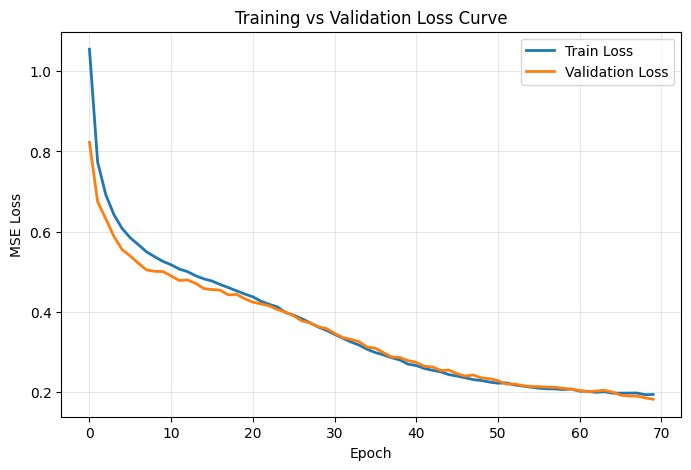

In [ ]:
#for overfitting check:
import matplotlib.pyplot as plt

# Assume you stored loss history during training — if not, we’ll quickly modify next cell to capture it
# For now, let's assume you saved: train_losses and val_losses lists

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# --- Two-Hidden-Layer sweep (short) ---
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error

# Reusable 2-hidden-layer model
class SavoniusANN_v2(nn.Module):
    def __init__(self, input_dim, h1, h2, output_dim=1, dropout1=0.4, dropout2=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout1),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(h2, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# Sweep configs (H1, H2)
configs = [(128,64), (64,32), (32,16), (128,32), (64,16)]

# Training hyperparams
lr = 1e-3
weight_decay = 1e-4
epochs = 70

results = {}

for (h1, h2) in configs:
    model = SavoniusANN_v2(input_dim=X_train_scaled.shape[1], h1=h1, h2=h2,
                           dropout1=0.4, dropout2=0.2).to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state = None

    for ep in range(epochs):
        # train on full training split (not combined train+val here)
        model.train()
        opt.zero_grad()
        pred = model(X_train_tensor)
        loss = criterion(pred, y_train_tensor)
        loss.backward()
        opt.step()

        # validate
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor)

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_state = model.state_dict()

    # save best validation loss for config
    results[(h1,h2)] = best_val_loss
    print(f"Config H1={h1:3d}, H2={h2:3d} -> Best Val MSE: {best_val_loss:.6f}")

# Report best config
best_config = min(results, key=results.get)
print("\n✅ Best two-layer config:", best_config, "with Val MSE =", results[best_config])


Config H1=128, H2= 64 -> Best Val MSE: 0.289152
Config H1= 64, H2= 32 -> Best Val MSE: 0.484532
Config H1= 32, H2= 16 -> Best Val MSE: 0.578736
Config H1=128, H2= 32 -> Best Val MSE: 0.420739
Config H1= 64, H2= 16 -> Best Val MSE: 0.474977

✅ Best two-layer config: (128, 64) with Val MSE = 0.2891519069671631


In [ ]:
# --- Retrain best 2-hidden-layer model on full train+val ---
# Combine train and val
X_combined = np.vstack((X_train_scaled, X_val_scaled))
y_combined = np.vstack((y_train_scaled, y_val_scaled))

X_combined_tensor = torch.tensor(X_combined, dtype=torch.float32).to(device)
y_combined_tensor = torch.tensor(y_combined, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

# Define best model
best_two_layer = SavoniusANN_v2(input_dim=X_train_scaled.shape[1],
                                h1=128, h2=64,
                                dropout1=0.4, dropout2=0.2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(best_two_layer.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 70

best_val_loss = float('inf')
for ep in range(epochs):
    best_two_layer.train()
    optimizer.zero_grad()
    preds = best_two_layer(X_combined_tensor)
    loss = criterion(preds, y_combined_tensor)
    loss.backward()
    optimizer.step()

print("✅ Final Two-Layer Model Trained")

# --- Evaluate on Test Set ---
best_two_layer.eval()
with torch.no_grad():
    y_pred_test = best_two_layer(X_test_tensor)
    mse_test = mean_squared_error(y_test_scaled.cpu().numpy(), y_pred_test.cpu().numpy())
    r2_test = r2_score(y_test_scaled.cpu().numpy(), y_pred_test.cpu().numpy())

print(f"🎯 Two-Layer Model Test MSE: {mse_test:.6f}")
print(f"🎯 Two-Layer Model Test R²:  {r2_test:.4f}")


✅ Final Two-Layer Model Trained


AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [ ]:
# --- Retrain best 2-hidden-layer model on full train+val ---
# Combine train and val
X_combined = np.vstack((X_train_scaled, X_val_scaled))
y_combined = np.vstack((y_train_scaled, y_val_scaled))

X_combined_tensor = torch.tensor(X_combined, dtype=torch.float32).to(device)
y_combined_tensor = torch.tensor(y_combined, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

# Define best model
best_two_layer = SavoniusANN_v2(input_dim=X_train_scaled.shape[1],
                                h1=128, h2=64,
                                dropout1=0.4, dropout2=0.2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(best_two_layer.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 70

best_val_loss = float('inf')
for ep in range(epochs):
    best_two_layer.train()
    optimizer.zero_grad()
    preds = best_two_layer(X_combined_tensor)
    loss = criterion(preds, y_combined_tensor)
    loss.backward()
    optimizer.step()

print("✅ Final Two-Layer Model Trained")

# --- Evaluate on Test Set ---
best_two_layer.eval()
with torch.no_grad():
    y_pred_test = best_two_layer(X_test_tensor).cpu().numpy()

# Compute metrics using NumPy arrays
mse_test = mean_squared_error(y_test_scaled, y_pred_test)
r2_test = r2_score(y_test_scaled, y_pred_test)

print(f"🎯 Two-Layer Model Test MSE: {mse_test:.6f}")
print(f"🎯 Two-Layer Model Test R²:  {r2_test:.4f}")


✅ Final Two-Layer Model Trained
🎯 Two-Layer Model Test MSE: 0.405410
🎯 Two-Layer Model Test R²:  0.6097


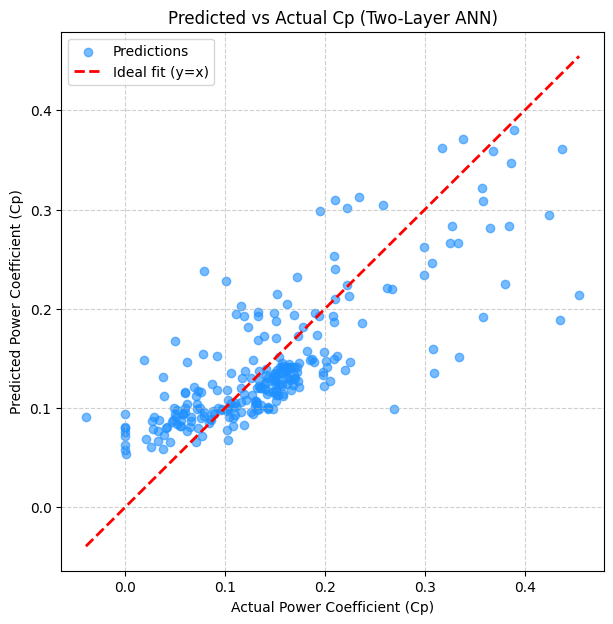

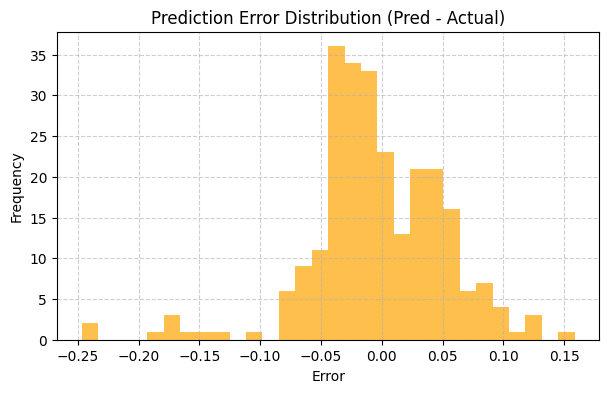

Mean Absolute Error (unscaled): 0.041509
Predicted Cp Range: 0.0542 → 0.3802
Actual Cp Range: -0.0392 → 0.4544


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Inverse transform to get back to original Cp values ---
y_pred_unscaled = scaler_y.inverse_transform(y_pred_test)
y_test_unscaled = scaler_y.inverse_transform(y_test_scaled)

# --- Compute test errors ---
errors = y_pred_unscaled - y_test_unscaled

# --- Plot 1: Predicted vs Actual ---
plt.figure(figsize=(7, 7))
plt.scatter(y_test_unscaled, y_pred_unscaled, color='dodgerblue', alpha=0.6, label='Predictions')
plt.plot([y_test_unscaled.min(), y_test_unscaled.max()],
         [y_test_unscaled.min(), y_test_unscaled.max()],
         'r--', lw=2, label='Ideal fit (y=x)')
plt.xlabel("Actual Power Coefficient (Cp)")
plt.ylabel("Predicted Power Coefficient (Cp)")
plt.title("Predicted vs Actual Cp (Two-Layer ANN)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Plot 2: Error distribution ---
plt.figure(figsize=(7, 4))
plt.hist(errors, bins=30, color='orange', alpha=0.7)
plt.title("Prediction Error Distribution (Pred - Actual)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Optional summary ---
print(f"Mean Absolute Error (unscaled): {np.mean(np.abs(errors)):.6f}")
print(f"Predicted Cp Range: {y_pred_unscaled.min():.4f} → {y_pred_unscaled.max():.4f}")
print(f"Actual Cp Range: {y_test_unscaled.min():.4f} → {y_test_unscaled.max():.4f}")


In [ ]:
import matplotlib.pyplot as plt

# ---- Predictions for both models ----
with torch.no_grad():
    y_pred_test_1 = best_model(X_test_tensor).cpu().numpy()
    y_pred_test_2 = best_two_layer(X_test_tensor).cpu().numpy()

# ---- Inverse transform back to real Cp values ----
y_pred_test_1_unscaled = y_scaler.inverse_transform(y_pred_test_1)
y_pred_test_2_unscaled = y_scaler.inverse_transform(y_pred_test_2)
y_test_unscaled = y_scaler.inverse_transform(y_test_scaled)

# ---- Plot comparison ----
plt.figure(figsize=(6,6))
plt.scatter(y_test_unscaled, y_pred_test_1_unscaled,
            alpha=0.5, label='1-layer model', color='orange')
plt.scatter(y_test_unscaled, y_pred_test_2_unscaled,
            alpha=0.5, label='2-layer model', color='green')
plt.plot([-0.05, 0.45], [-0.05, 0.45], 'k--', lw=2, label='Ideal line y=x')

plt.title('Predicted vs Actual Cp (1-layer vs 2-layer)')
plt.xlabel('Actual Cp')
plt.ylabel('Predicted Cp')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'y_scaler' is not defined

In [ ]:
import torch
import pickle

# Save model state
torch.save(best_two_layer.state_dict(), "best_two_layer_model.pth")

# Save the scaler (so you can inverse transform later)
with open("y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)

print("✅ Model and scaler saved!")


✅ Model and scaler saved!


In [ ]:
from google.colab import files

files.download("best_two_layer_model.pth")
files.download("y_scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import numpy as np

# --- Load the saved dictionary for the one-layer model ---
with open("best_savonius_model.pkl", "rb") as f:
    one_layer_save_dict = pickle.load(f)

# Initialize the one-layer model and load state dict
# Assuming SavoniusANN class is defined as in previous cells
one_layer_model = SavoniusANN(input_dim=13, hidden_dim=128, output_dim=1, dropout=0.4).to(device) # Use the best hyperparameters found
one_layer_model.load_state_dict(one_layer_save_dict["model_state_dict"])

# Load the fitted scalers from the one-layer model save file
scaler_X = one_layer_save_dict["scaler_X"]
scaler_y = one_layer_save_dict["scaler_y"]


# --- Load the state dict for the two-layer model ---
# Assuming SavoniusANN_v2 class is defined
two_layer_model = SavoniusANN_v2(input_dim=X_train_scaled.shape[1], h1=128, h2=64, dropout1=0.4, dropout2=0.2).to(device) # Use the best hyperparameters found
two_layer_model.load_state_dict(torch.load("best_two_layer_model.pth", map_location=device))


# --- Set to eval mode ---
one_layer_model.eval()
two_layer_model.eval()

# --- Prepare test data ---
# Use the loaded scaler_X to scale the original X_test DataFrame
X_test_scaled = scaler_X.transform(X_test)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# Use the loaded scaler_y to scale the original y_test DataFrame
y_test_scaled = scaler_y.transform(y_test)


# --- Evaluate 1-layer model ---
with torch.no_grad():
    y_pred_1_scaled = one_layer_model(X_test_tensor).cpu().numpy()

# --- Evaluate 2-layer model ---
with torch.no_grad():
    y_pred_2_scaled = two_layer_model(X_test_tensor).cpu().numpy()

# --- Compute metrics (unscaled) ---
# Use the loaded scaler_y to inverse transform both predictions and actuals
y_test_unscaled = scaler_y.inverse_transform(y_test_scaled)
y_pred_1_unscaled = scaler_y.inverse_transform(y_pred_1_scaled)
y_pred_2_unscaled = scaler_y.inverse_transform(y_pred_2_scaled)


mse_1 = mean_squared_error(y_test_unscaled, y_pred_1_unscaled)
r2_1 = r2_score(y_test_unscaled, y_pred_1_unscaled)

mse_2 = mean_squared_error(y_test_unscaled, y_pred_2_unscaled)
r2_2 = r2_score(y_test_unscaled, y_pred_2_unscaled)

print(f"🔹 One-Layer Model → MSE: {mse_1:.6f}, R²: {r2_1:.4f}")
print(f"🔹 Two-Layer Model → MSE: {mse_2:.6f}, R²: {r2_2:.4f}")

🔹 One-Layer Model → MSE: 0.004779, R²: 0.4086
🔹 Two-Layer Model → MSE: 0.003154, R²: 0.6097


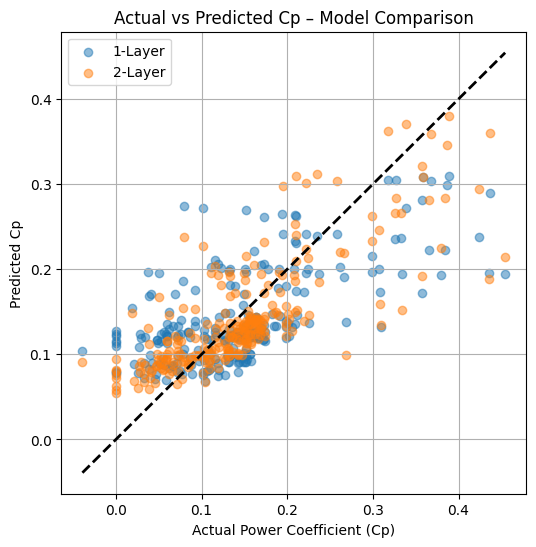

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot for both models
plt.figure(figsize=(6,6))
plt.scatter(y_test_unscaled, y_pred_1_unscaled, alpha=0.5, label='1-Layer', color='tab:blue')
plt.scatter(y_test_unscaled, y_pred_2_unscaled, alpha=0.5, label='2-Layer', color='tab:orange')
plt.plot([y_test_unscaled.min(), y_test_unscaled.max()],
         [y_test_unscaled.min(), y_test_unscaled.max()],
         'k--', lw=2)

plt.xlabel("Actual Power Coefficient (Cp)")
plt.ylabel("Predicted Cp")
plt.title("Actual vs Predicted Cp – Model Comparison")
plt.legend()
plt.grid(True)
plt.show()


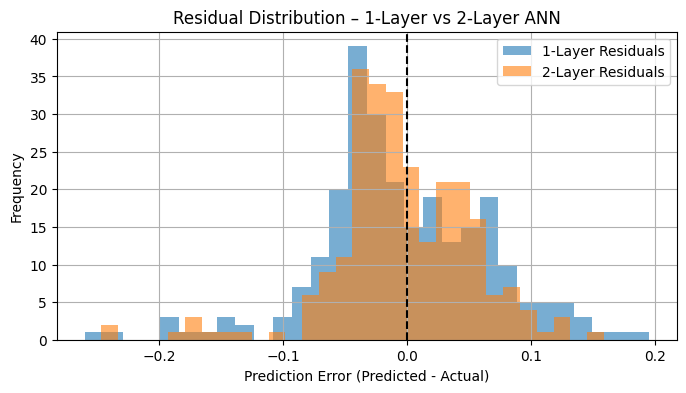

In [ ]:
# Compute residuals
residuals_1 = y_pred_1_unscaled.flatten() - y_test_unscaled.flatten()
residuals_2 = y_pred_2_unscaled.flatten() - y_test_unscaled.flatten()

# Plot residual distributions
plt.figure(figsize=(8,4))
plt.hist(residuals_1, bins=30, alpha=0.6, label='1-Layer Residuals', color='tab:blue')
plt.hist(residuals_2, bins=30, alpha=0.6, label='2-Layer Residuals', color='tab:orange')
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("Residual Distribution – 1-Layer vs 2-Layer ANN")
plt.legend()
plt.grid(True)
plt.show()


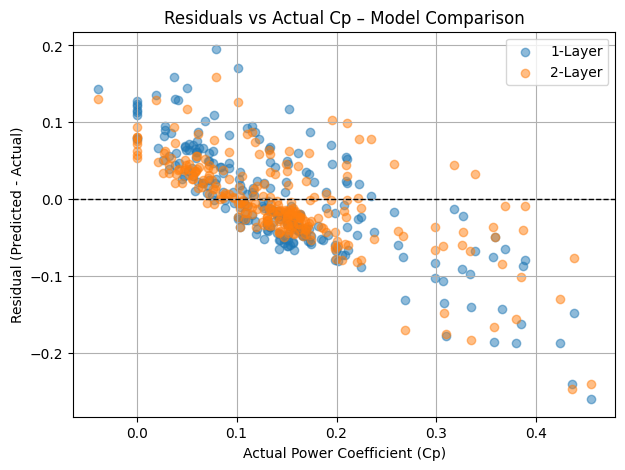

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test_unscaled, residuals_1, alpha=0.5, label='1-Layer', color='tab:blue')
plt.scatter(y_test_unscaled, residuals_2, alpha=0.5, label='2-Layer', color='tab:orange')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Actual Power Coefficient (Cp)")
plt.ylabel("Residual (Predicted - Actual)")
plt.title("Residuals vs Actual Cp – Model Comparison")
plt.legend()
plt.grid(True)
plt.show()
